<a href="https://colab.research.google.com/github/AtulMore2327/Intro-to-Machine-Learning/blob/main/Cat_vs_Dog_Image_Classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from zipfile import ZipFile
dataset = '/content/drive/MyDrive/Data  Set/14/archive (14).zip'
with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The DataSet is extracted')


The DataSet is extracted


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
with_cats_files = os.listdir('/content/test/cats')
with_dogs_files = os.listdir('/content/test/dogs')

In [ ]:
with_cat_files[:5]

['cat_60.jpg', 'cat_5.jpg', 'cat_116.jpg', 'cat_118.jpg', 'cat_585.jpg']

In [ ]:
with_dogs_files[-5:]

['dog_147.jpg', 'dog_142.jpg', 'dog_355.jpg', 'dog_443.jpg', 'dog_75.jpg']

In [ ]:
len(with_cats_files)

70

In [ ]:
len(with_dogs_files)

70

In [ ]:
with_cats_files = [1]*70
with_dogs_files = [0]*70

In [ ]:
with_cats_files[:5]

[1, 1, 1, 1, 1]

In [ ]:
with_dogs_files[:5]

[0, 0, 0, 0, 0]

In [ ]:
labels = with_cats_files + with_dogs_files

In [ ]:
labels[:5]

[1, 1, 1, 1, 1]

In [ ]:
labels[-5:]

[0, 0, 0, 0, 0]

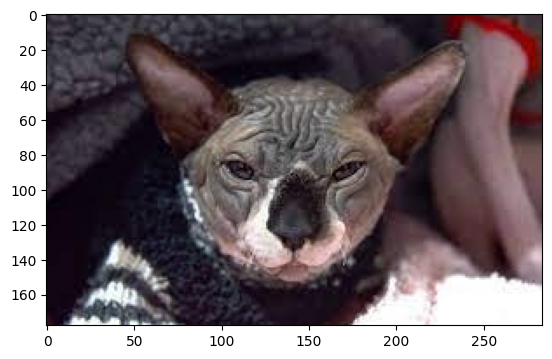

In [ ]:
img = mpimg.imread('/content/test/cats/cat_116.jpg')
imgplot = plt.imshow(img)
plt.show()

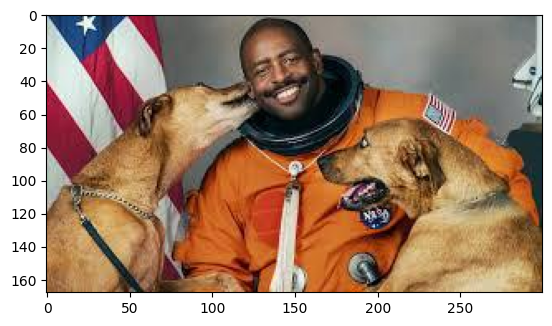

In [ ]:
img = mpimg.imread('/content/test/dogs/dog_147.jpg')
imgplot = plt.imshow(img)
plt.show()

In [ ]:
import os
from PIL import Image
import numpy as np

# Corrected path: changed 'cat' to 'cats'
with_cats_path = '/content/test/cats'

data = []

# Re-assign with_cats_files to contain actual filenames, overriding previous integer list
with_cats_files = os.listdir(with_cats_path)

for img_file in with_cats_files:
  image =  Image.open(os.path.join(with_cats_path, img_file))
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

# No change needed for with_dogs_path
with_dogs_path = '/content/test/dogs'

# Re-assign with_dogs_files to contain actual filenames, overriding previous integer list
with_dogs_files = os.listdir(with_dogs_path)

for img_file in with_dogs_files:
  image =  Image.open(os.path.join(with_dogs_path, img_file))
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

array([[[ 81, 153,  59],
        [ 81, 151,  54],
        [ 77, 139,  46],
        ...,
        [107, 175,  86],
        [103, 170,  79],
        [107, 164,  73]],

       [[ 78, 160,  55],
        [ 91, 166,  62],
        [ 92, 163,  59],
        ...,
        [ 88, 168,  52],
        [ 90, 170,  52],
        [102, 169,  59]],

       [[ 91, 165,  64],
        [ 93, 172,  70],
        [ 91, 169,  63],
        ...,
        [103, 170,  46],
        [ 96, 167,  43],
        [ 99, 165,  49]],

       ...,

       [[ 72, 172,  39],
        [ 75, 145,  33],
        [ 82, 139,  24],
        ...,
        [ 63, 134,  36],
        [ 52, 139,  11],
        [ 77, 172,  17]],

       [[ 92, 180,  42],
        [ 61, 140,  11],
        [ 84, 154,  22],
        ...,
        [ 66, 134,  29],
        [ 77, 159,  29],
        [ 88, 178,  18]],

       [[ 85, 164,  20],
        [ 74, 162,  14],
        [ 83, 168,  19],
        ...,
        [ 49, 116,  19],
        [ 92, 178,  61],
        [ 89, 162,  22]]], dtype=uint8)
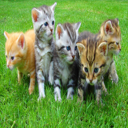

In [ ]:
data[0]

array([[[ 96, 103,  53],
        [ 97, 104,  51],
        [ 97, 104,  50],
        ...,
        [ 57,  60,  35],
        [ 54,  58,  33],
        [ 54,  58,  35]],

       [[ 96, 103,  53],
        [ 97, 104,  51],
        [ 97, 104,  50],
        ...,
        [ 58,  63,  35],
        [ 57,  61,  33],
        [ 55,  59,  33]],

       [[ 97, 104,  54],
        [ 97, 104,  51],
        [ 97, 104,  50],
        ...,
        [ 60,  65,  34],
        [ 59,  64,  33],
        [ 57,  62,  33]],

       ...,

       [[ 52,  57,  20],
        [ 52,  56,  20],
        [ 52,  58,  20],
        ...,
        [ 72,  79,  37],
        [ 73,  81,  39],
        [ 78,  85,  43]],

       [[ 47,  54,  20],
        [ 46,  53,  19],
        [ 50,  56,  20],
        ...,
        [ 66,  75,  32],
        [ 68,  77,  34],
        [ 70,  79,  36]],

       [[ 45,  52,  18],
        [ 45,  52,  18],
        [ 49,  55,  19],
        ...,
        [ 67,  76,  33],
        [ 64,  74,  30],
        [ 66,  75,  32]]], dtype=uint8)
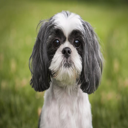

In [ ]:
data[81]

In [ ]:
x_train = np.array(data)
y_train = np.array(labels)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_train,y_train,test_size=0.2,random_state=2)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
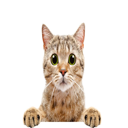

In [ ]:
x_train[0]

In [ ]:
y_train[87]

np.int64(0)

In [ ]:
x_train = x_test/255
x_test = x_test/255

In [ ]:
x_train[0]

array([[[0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        ...,
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571]],

       [[0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        ...,
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571]],

       [[0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        ...,
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571]],

       ...,

       [[0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0.01428571, 0.01428571],
        [0.01428571, 0

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
num_of_classes = 2
model = keras.Sequential()

model.add(keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128,activation='relu'))

model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(64,activation='relu'))

model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,400,706 (28.23 MB)

 Trainable params: 7,400,706 (28.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(x_train,y_train,validation_split = 0.1, epochs = 5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5600 - loss: 0.6924 - val_accuracy: 0.3333 - val_loss: 0.7125
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - accuracy: 0.6000 - loss: 0.6988 - val_accuracy: 0.3333 - val_loss: 0.7421
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step - accuracy: 0.5600 - loss: 0.6685 - val_accuracy: 0.3333 - val_loss: 0.7576
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - accuracy: 0.5600 - loss: 0.6641 - val_accuracy: 0.3333 - val_loss: 0.7883
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step - accuracy: 0.5600 - loss: 0.6921 - val_accuracy: 0.3333 - val_loss: 0.7415


Path of the image to be predicted: /content/test/dogs/dog_159.jpg


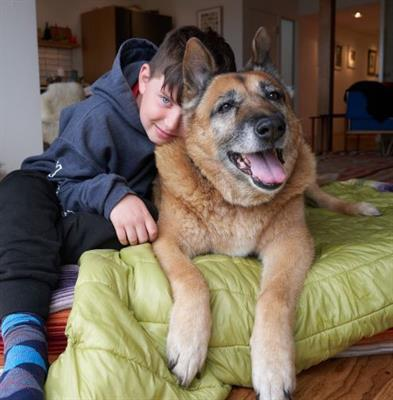

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[0.00140244 0.99998474]]
1
The image is a Cat


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The image is a Cat')

else:

  print('The image is a Dog')